In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def beale_function(x, y):
    term1 = (1.5 - x + x*y)**2
    term2 = (2.25 - x + x*y**2)**2
    term3 = (2.625 - x + x*y**3)**2
    return term1 + term2 + term3 + 1e-3

# choose a funtion here
def my_function(x, y):
    # return 8 * (x - 1) ** 2 * (1.3 * x ** 2 + 2 * x + 1) + 0.5 * (y - 4) ** 2
    # return (x if x > 0 else -x) + (y if y > 0 else -y)
    # return 100 * x ** 2 + y ** 2
    return beale_function(x, y)

# visualize area [x1, x2] x [y1, y2]
def generate_loss_surface():
    # x1 = -1
    # x2 = 1
    # y1 = -0.5
    # y2 = 1.5
    
    # x1 = 0
    # x2 = 1.5
    # y1 = 3
    # y2 = 7
    
    # x1 = -1
    # x2 = 0
    # y1 = 0
    # y2 = 5
    
    x1 = -2
    x2 = 5
    y1 = -2
    y2 = 2
    
    # x1 = -2
    # x2 = 2
    # y1 = -2
    # y2 = 2
    
    x = np.linspace(x1, x2, 100)
    y = np.linspace(y1, y2, 100)
    
    # x = np.linspace(-1.5, 1.5, 100)
    # y = np.linspace(-1.5, 1.5, 100)
    
    # x = np.linspace(-1.5, 1.5, 100)
    # y = np.linspace(0, 7, 100)
    
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i,j] = my_function(X[i,j], Y[i,j])
    return X, Y, Z

##################################################################
# set an initial point


# initial_point = torch.tensor([0.25, 6.75])
# initial_point = torch.tensor([0.0, 4.0])
# initial_point = torch.tensor([-1.0, 1.0])
# initial_point = torch.tensor([3.2, 0.6])
# initial_point = torch.tensor([1.5, 0.5])
# initial_point = torch.tensor([4.0, -2.0])
# initial_point = torch.tensor([0.0, 0.0])
initial_point = torch.tensor([-1.0, -1.0])
# initial_point = torch.tensor([2.8, 0.4])
#################################################################

iterations = 2500
learning_rate = 0.01
scale_down = 0.2 # for zeroth-order


optimizer_configs = {
    "Adam": {
        "optimizer": torch.optim.Adam,
        "lr": learning_rate,
        "betas": (0.9, 0.999)
    },
    "MeZO":{},
    "AdaMeZO":{},
}


results = {name: {"loss": [], "params": []} for name in optimizer_configs}
norm_history = []
for opt_name, config in optimizer_configs.items():
    try:
        params = initial_point.clone().detach().requires_grad_(True)
        optimizer = config["optimizer"]([params], **{k:v for k,v in config.items() if k != "optimizer"})
        
        param_history = []
        param_history.append(params.detach().numpy().copy())
        loss = my_function(params[0], params[1])
        results[opt_name]["loss"].append(loss.item())
        
        for _ in range(iterations):
            
            
            optimizer.zero_grad()
            loss = my_function(params[0], params[1])
            loss.backward()
            optimizer.step()
            param_history.append(params.detach().numpy().copy())
            norm_history.append(np.sum((params.detach().numpy() - param_history[-2]) ** 2) ** 0.5)
            loss = my_function(params[0], params[1])
            results[opt_name]["loss"].append(loss.item())
        
        results[opt_name]["params"] = np.array(param_history)
        results[opt_name]["gnorms"] = np.array(norm_history)
    except KeyError:
        pass

In [ ]:
param_history = []
mu = 0.001
g = torch.Generator(device='cpu')
projection_history = []
direction_history = []
norm_history = []
seed_history = []
w = initial_point.clone().detach().requires_grad_(True)
opt_name = 'MeZO'

seed_bias = 0
seedscope = 2
good = True

################################################################################
# good: 
#   If set to True, optimizer will use a random seed to generate random gradient directions
#   If set to False, optimizer will use a fixed look to dset, for all possible gradient directions

# seedscope:
#   How many possible explore directions in total

################################################################################


learning_rate = learning_rate * scale_down

# dset = [torch.tensor([1.0, 0.0]), torch.tensor([0.0, 1.0])]
dset = [torch.tensor([0.7071, 0.7071]), torch.tensor([-0.7071, 0.7071])]

for _ in range(iterations):
    
    # seed = np.random.randint(0, 10000000)
    # seed = (_ + seed_bias) % seedscope
    seed = (_ + seed_bias) % seedscope
    
    if good:
        g.manual_seed(seed)
        z = torch.randn(size=w.size(), generator=g)
    else:
        # print('not good')
        z = dset[0] if seed == 0 else dset[1]
    
    param_history.append(w.detach().numpy().copy())
    loss = my_function(w[0], w[1])
    results[opt_name]["loss"].append(loss.item())
    direction_history.append(z)
    
    
    w = w + mu * z
    loss1 = my_function(w[0], w[1])
    w = w - 2 * mu * z
    loss2 = my_function(w[0], w[1])
    w = w + mu * z
    p = (loss1 - loss2) / (2 * mu)
    
    update = learning_rate * p * z
    w = w - update
    projection_history.append(p)
    norm_history.append(torch.norm(update).item())
    

results[opt_name]["params"] = np.array(param_history)
results[opt_name]["gnorms"] = np.array(norm_history)

In [ ]:
param_history = []
# mu = 0.0001
# learning_rate = 0.001
g = torch.Generator(device='cpu')
projection_history = []
direction_history = []
seed_history = []
norm_history = []
w = initial_point.clone().detach().requires_grad_(True)
opt_name = 'AdaMeZO'
hw = 20     # horizontal window
beta1 = 0.7
beta2 = 0.9
seed_bias = 0


for _ in range(iterations):
    
    seed = (_ + seed_bias) % seedscope
    
    if good:
        g.manual_seed(seed)
        z = torch.randn(size=w.size(), generator=g)
    else:
        # print('not good')
        z = dset[0] if seed == 0 else dset[1]
    
    param_history.append(w.detach().numpy().copy())
    loss = my_function(w[0], w[1])
    results[opt_name]["loss"].append(loss.item())
    direction_history.append(z)
    
    
    w = w + mu * z
    loss1 = my_function(w[0], w[1])
    w = w - 2 * mu * z
    loss2 = my_function(w[0], w[1])
    w = w + mu * z
    p = (loss1 - loss2) / (2 * mu)
    
    projection_history.append(p)
    seed_history.append(seed)
    
    
    if _ < hw + 1:
        g.manual_seed(seed)
        update = learning_rate * p * torch.randn(size=w.size(), generator=g)
        w = w - update
        loss = my_function(w[0], w[1])
        norm_history.append(torch.norm(update).item())
    else:
        m = torch.zeros(size=w.size())
        v = torch.zeros(size=w.size())
        for i in range(hw):
            idx = -(i+1)
            g.manual_seed(seed_history[idx])
            z = torch.randn(size=w.size(), generator=g)
            m += (beta1 ** i) * (projection_history[idx] * z)
            v += (beta2 ** i) * (projection_history[idx] ** 2) * (z ** 2)
            
            
            # print(i)
            # print(beta1 ** i)
        
        # v /= v.norm()
        update = learning_rate * m / (v ** 0.5 + 1e-8)
        w = w - update
        norm_history.append(torch.norm(update).item())

results[opt_name]["params"] = np.array(param_history)
results[opt_name]["gnorms"] = np.array(norm_history)

In [115]:
results['Adam']['gnorms'].sum(), results['MeZO']['gnorms'].sum(), results['AdaMeZO']['gnorms'].sum()

# tf3, (1.4142193411588064, 1.4243322202237323, 1.8576737062394386), 500, 0.01, 0.2
# tf2, (4.354970209982987, 5.5404819330142345, 5.320683644333258), 2500, 0.01, 0.2
# tf1, (3.0227014701373296, 4.665946733322926, 4.507765908478177), 600, 0.01, 1.0

(4.354970209982987, 5.5404819330142345, 5.320683644333258)

/tmp/ipykernel_693685/638862730.py:37: UserWarning: linewidths is ignored by contourf
  cf = ax2.contourf(X, Y, Z, levels=levels, cmap=cmap, norm=LogNorm(), alpha=1.0, contour=False, linewidths=0.0)
/tmp/ipykernel_693685/638862730.py:37: UserWarning: The following kwargs were not used by contour: 'contour'
  cf = ax2.contourf(X, Y, Z, levels=levels, cmap=cmap, norm=LogNorm(), alpha=1.0, contour=False, linewidths=0.0)


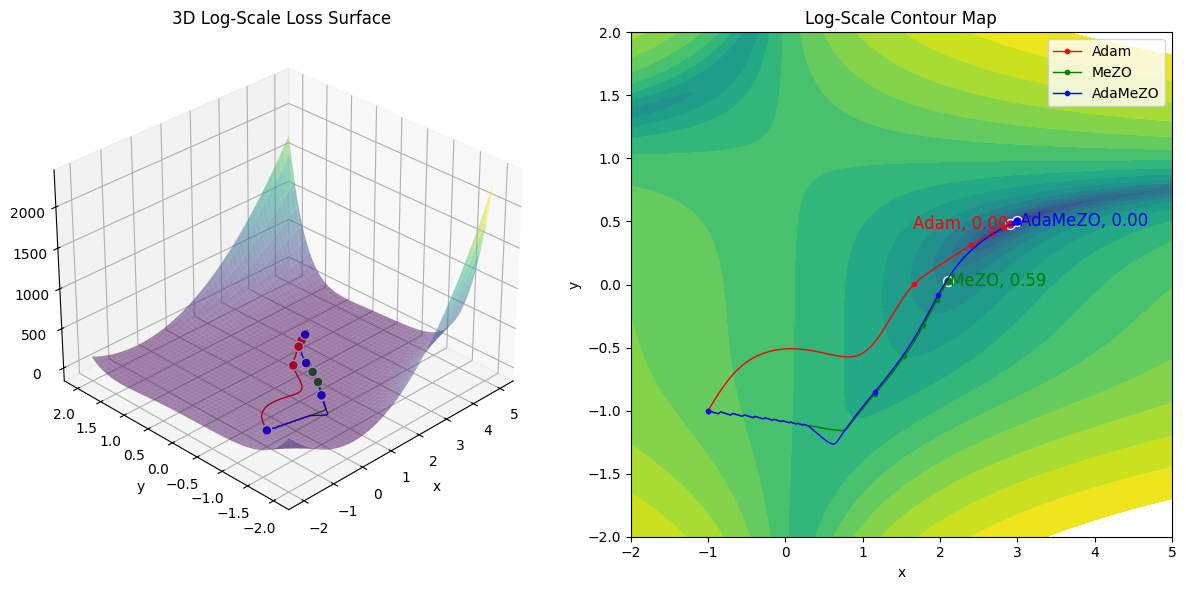


Final Loss Values:
Adam: 2.4868e-03
MeZO: 5.8685e-01
AdaMeZO: 1.0001e-03


In [ ]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(12, 6))
colors = {'Adam': 'red', 'MeZO': 'green', 'AdaMeZO': 'blue'}
X, Y, Z = generate_loss_surface()

cmap = 'viridis'

ax1 = plt.subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap=cmap, alpha=0.5, rstride=2, cstride=2)

for opt_name in optimizer_configs:
    try:
        traj = results[opt_name]["params"]
        loss = np.maximum(results[opt_name]["loss"], 1e-3)  # 确保loss值非负
        
        ax1.plot(traj[:,0], traj[:,1], loss, 
                color=colors[opt_name], lw=1, label=opt_name, alpha=1.0)
        ax1.scatter(traj[::iterations//5,0], traj[::iterations//5,1], loss[::iterations//5],
                color=colors[opt_name], s=50, edgecolor='w', alpha=1.0)
    except (TypeError, KeyError):
        pass
ax1.set(xlabel='x', ylabel='y', title='3D Log-Scale Loss Surface')
ax1.view_init(30, 225)

ax2 = plt.subplot(122)
levels = np.logspace(-3, 3
                     , 20)
cf = ax2.contourf(X, Y, Z, levels=levels, cmap=cmap, norm=LogNorm(), alpha=1.0, contour=False, linewidths=0.0)

for opt_name in optimizer_configs:
    try:
        traj = results[opt_name]["params"]
        final_loss = max(results[opt_name]['loss'][-1], 1e-3)
        ax2.plot(traj[:,0], traj[:,1], color=colors[opt_name], lw=1, 
                marker='o', markersize=3, markevery=iterations//5, label=opt_name)
        ax2.scatter(traj[-1,0], traj[-1,1], color=colors[opt_name], s=50, edgecolor='w')
        ax2.text(
            traj[-1,0] + (0.03 if opt_name != 'Adam' else -0.03),
            traj[-1,1],
            f"{opt_name}, {final_loss:.2f}",
            color=colors[opt_name],
            fontsize=12,
            ha='left' if opt_name != 'Adam' else 'right', 
            va='center'
        )
    except (TypeError, KeyError):
        pass
ax2.set(xlabel='x', ylabel='y', title='Log-Scale Contour Map', 
        xlim=[X.min(), X.max()], ylim=[Y.min(), Y.max()])

plt.legend()
plt.tight_layout()
plt.show()

print("\nFinal Loss Values:")
for opt_name in optimizer_configs:
    try:
        loss = results[opt_name]['loss'][-1]
        print(f"{opt_name}: {loss:.4e}")
    except:
        pass

/tmp/ipykernel_693685/1019886228.py:17: UserWarning: linewidths is ignored by contourf
  cf = ax.contourf(X, Y, Z, levels=levels, cmap=cmap, norm=LogNorm(), alpha=1.0, contour=False, linewidths=0.0)
/tmp/ipykernel_693685/1019886228.py:17: UserWarning: The following kwargs were not used by contour: 'contour'
  cf = ax.contourf(X, Y, Z, levels=levels, cmap=cmap, norm=LogNorm(), alpha=1.0, contour=False, linewidths=0.0)


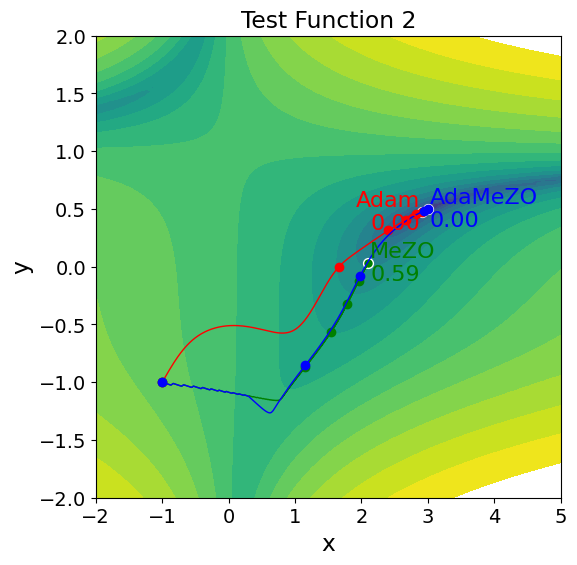

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

def set_fontscale(ax, scale=1.0):

    ax.title.set_fontsize(12 * scale)
    ax.xaxis.label.set_fontsize(12 * scale)
    ax.yaxis.label.set_fontsize(12 * scale)
    ax.tick_params(axis='both', labelsize=10 * scale)


levels = np.logspace(-3, 3, 20)
cf = ax.contourf(X, Y, Z, levels=levels, cmap=cmap, norm=LogNorm(), alpha=1.0, contour=False, linewidths=0.0)


for opt_name in optimizer_configs:
    try:
        traj = results[opt_name]["params"]
        final_loss = max(results[opt_name]['loss'][-1], 1e-3)
        ax.plot(traj[:,0], traj[:,1], color=colors[opt_name], lw=1, 
                marker='o', markersize=6, markevery=iterations//5, label=opt_name)
        ax.scatter(traj[-1,0], traj[-1,1], color=colors[opt_name], s=50, edgecolor='w')
        ax.text(
            traj[-1,0] + (0.03 if opt_name != 'Adam' else -0.03),
            traj[-1,1],
            f"{opt_name}\n{final_loss:.2f}",
            color=colors[opt_name],
            fontsize=16,
            ha='left' if opt_name != 'Adam' else 'right', 
            va='center'
        )
    except (TypeError, KeyError):
        pass
ax.set(xlabel='x', ylabel='y', title='Test Function 2', 
        xlim=[X.min(), X.max()], ylim=[Y.min(), Y.max()])
set_fontscale(ax, scale=1.4) 
